# GeoJam Data — Quick Check

Downloads `geojam_data.zip` from Google Drive, loads everything, and sanity-checks it.

In [1]:
!pip install -q geopandas

In [2]:
import gdown, zipfile, os, json
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

FILE_ID = "1N_8L_hBxg1u7eiif3NwFO54LINqGTXbx"
ZIP_NAME = "geojam_data.zip"
DATA_DIR = "geojam_data"

if not os.path.exists(ZIP_NAME):
    gdown.download(id=FILE_ID, output=ZIP_NAME, quiet=False)

with zipfile.ZipFile(ZIP_NAME) as zf:
    zf.extractall(".")

print("Contents:")
for f in sorted(os.listdir(DATA_DIR)):
    sz = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f"  {f:40s} {sz:8.2f} MB")

Downloading...
From (original): https://drive.google.com/uc?id=1N_8L_hBxg1u7eiif3NwFO54LINqGTXbx
From (redirected): https://drive.google.com/uc?id=1N_8L_hBxg1u7eiif3NwFO54LINqGTXbx&confirm=t&uuid=05cce98c-f40f-478c-9c33-9ede6826bfcd
To: /content/geojam_data.zip
100%|██████████| 233M/233M [00:10<00:00, 23.2MB/s]


Contents:
  README.txt                                   0.00 MB
  band_early_B02.npy                          26.90 MB
  band_early_B03.npy                          26.90 MB
  band_early_B04.npy                          26.90 MB
  band_early_B08.npy                          26.90 MB
  band_late_B02.npy                           26.90 MB
  band_late_B03.npy                           26.90 MB
  band_late_B04.npy                           26.90 MB
  band_late_B08.npy                           26.90 MB
  msoa_base.gpkg                               1.79 MB
  msoa_full.gpkg                               1.83 MB
  ndvi_early.npy                              26.90 MB
  ndvi_late.npy                               26.90 MB
  raster_meta.json                             0.00 MB


In [3]:
with open(os.path.join(DATA_DIR, "raster_meta.json")) as f:
    meta = json.load(f)

print(json.dumps(meta, indent=2))

{
  "crs": "EPSG:27700",
  "transform": [
    20.0,
    0.0,
    504019.2157812669,
    0.0,
    -20.0,
    201596.86913283129
  ],
  "shape": [
    2355,
    2856
  ],
  "resolution_m": 20,
  "bounds_wgs84": [
    -0.51,
    51.28,
    0.33,
    51.69
  ],
  "early_date": "2019-07-23",
  "late_date": "2024-07-29",
  "early_scene_ids": [
    "S2B_MSIL2A_20190723T105629_R094_T31UCT_20201106T013939",
    "S2B_MSIL2A_20190723T105629_R094_T31UCS_20201005T184044",
    "S2B_MSIL2A_20190723T105629_R094_T30UYC_20201005T184045",
    "S2B_MSIL2A_20190723T105629_R094_T30UYB_20201005T184040",
    "S2B_MSIL2A_20190723T105629_R094_T30UXC_20201005T184035",
    "S2B_MSIL2A_20190723T105629_R094_T30UXB_20201005T184037"
  ],
  "late_scene_ids": [
    "S2B_MSIL2A_20240729T110619_R137_T31UCT_20240729T135102",
    "S2B_MSIL2A_20240729T110619_R137_T31UCS_20240729T135102",
    "S2B_MSIL2A_20240729T110619_R137_T30UYC_20240729T135102",
    "S2B_MSIL2A_20240729T110619_R137_T30UYB_20240729T135102",
    "S2B_MSIL2

In [4]:
bands_early = {b: np.load(os.path.join(DATA_DIR, f"band_early_{b}.npy")) for b in meta["band_order"]}
bands_late  = {b: np.load(os.path.join(DATA_DIR, f"band_late_{b}.npy"))  for b in meta["band_order"]}
ndvi_early  = np.load(os.path.join(DATA_DIR, "ndvi_early.npy"))
ndvi_late   = np.load(os.path.join(DATA_DIR, "ndvi_late.npy"))

print("Band shapes:")
for b, arr in bands_early.items():
    print(f"  {b}: early {arr.shape} {arr.dtype}  late {bands_late[b].shape} {bands_late[b].dtype}")
print(f"  NDVI: early {ndvi_early.shape}  late {ndvi_late.shape}")

print("\nValue ranges:")
for b in meta["band_order"]:
    print(f"  {b} early: [{bands_early[b].min():.4f}, {bands_early[b].max():.4f}]")
print(f"  NDVI early: [{ndvi_early.min():.3f}, {ndvi_early.max():.3f}]")
print(f"  NDVI late:  [{ndvi_late.min():.3f}, {ndvi_late.max():.3f}]")

Band shapes:
  B02: early (2355, 2856) float32  late (2355, 2856) float32
  B03: early (2355, 2856) float32  late (2355, 2856) float32
  B04: early (2355, 2856) float32  late (2355, 2856) float32
  B08: early (2355, 2856) float32  late (2355, 2856) float32
  NDVI: early (2355, 2856)  late (2355, 2856)

Value ranges:
  B02 early: [0.0000, 1.6019]
  B03 early: [0.0000, 1.5260]
  B04 early: [0.0000, 1.5618]
  B08 early: [0.0000, 1.5402]
  NDVI early: [-0.849, 0.927]
  NDVI late:  [-0.510, 0.786]


In [5]:
msoa_base = gpd.read_file(os.path.join(DATA_DIR, "msoa_base.gpkg"))
msoa_full = gpd.read_file(os.path.join(DATA_DIR, "msoa_full.gpkg"))

print(f"msoa_base: {len(msoa_base)} rows, {len(msoa_base.columns)} columns")
print(f"  Columns: {list(msoa_base.columns)}")
print(f"  CRS: {msoa_base.crs}")
print()
print(f"msoa_full: {len(msoa_full)} rows, {len(msoa_full.columns)} columns")
print(f"  Extra columns: {[c for c in msoa_full.columns if c not in msoa_base.columns]}")
print()
print("Nulls in msoa_base:")
print(msoa_base.drop(columns="geometry").isnull().sum().to_string())
print()
print("Nulls in msoa_full:")
print(msoa_full.drop(columns="geometry").isnull().sum().to_string())

msoa_base: 1011 rows, 8 columns
  Columns: ['MSOA21CD', 'MSOA21NM', 'population', 'area_km2', 'pop_density', 'dist_to_centre_km', 'dist_to_park_km', 'geometry']
  CRS: EPSG:4326

msoa_full: 1011 rows, 13 columns
  Extra columns: ['mean_ndvi_early', 'mean_ndvi_late', 'mean_delta_ndvi', 'prop_greener', 'prop_greyer']

Nulls in msoa_base:
MSOA21CD             0
MSOA21NM             0
population           0
area_km2             0
pop_density          0
dist_to_centre_km    0
dist_to_park_km      0

Nulls in msoa_full:
MSOA21CD             0
MSOA21NM             0
population           0
area_km2             0
pop_density          0
dist_to_centre_km    0
dist_to_park_km      0
mean_ndvi_early      1
mean_ndvi_late       1
mean_delta_ndvi      1
prop_greener         1
prop_greyer          1


In [6]:
msoa_base.describe()

,population,area_km2,pop_density,dist_to_centre_km,dist_to_park_km
count,1011.000000,1011.000000,1011.000000,1011.000000,1011.000000
mean,99.432245,1.707712,105.917131,12.567627,0.293798
std,212.505143,2.677679,265.300516,6.081713,0.558222
min,0.000000,0.293936,0.000000,0.412984,0.000000
25%,6.500000,0.704016,4.644012,7.726410,0.092043
50%,39.000000,1.123950,27.136789,12.247602,0.203006
75%,97.500000,1.737285,83.046078,16.802344,0.364864
max,2371.000000,47.805097,3545.379748,38.658810,10.113612


In [7]:
msoa_full.describe()

,population,area_km2,pop_density,dist_to_centre_km,dist_to_park_km,mean_ndvi_early,mean_ndvi_late,mean_delta_ndvi,prop_greener,prop_greyer
count,1011.000000,1011.000000,1011.000000,1011.000000,1011.000000,1010.000000,1010.000000,1010.000000,1010.0,1010.0
mean,99.432245,1.707712,105.917131,12.567627,0.293798,0.423630,0.277243,-0.146387,1.0,0.0
std,212.505143,2.677679,265.300516,6.081713,0.558222,0.106232,0.076305,0.035167,0.0,0.0
min,0.000000,0.293936,0.000000,0.412984,0.000000,0.099203,0.057528,-0.249566,1.0,0.0
25%,6.500000,0.704016,4.644012,7.726410,0.092043,0.349059,0.222037,-0.170582,1.0,0.0
50%,39.000000,1.123950,27.136789,12.247602,0.203006,0.422852,0.276720,-0.146124,1.0,0.0
75%,97.500000,1.737285,83.046078,16.802344,0.364864,0.496180,0.329518,-0.122581,1.0,0.0
max,2371.000000,47.805097,3545.379748,38.658810,10.113612,0.715784,0.505248,-0.003730,1.0,0.0


In [8]:
def make_rgb(bands, gain=3.0):
    rgb = np.stack([bands["B04"], bands["B03"], bands["B02"]], axis=-1)
    return np.clip(rgb * gain, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(make_rgb(bands_early))
axes[0].set_title(f"True colour — {meta['early_date']}")
axes[0].axis("off")
axes[1].imshow(make_rgb(bands_late))
axes[1].set_title(f"True colour — {meta['late_date']}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

im0 = axes[0].imshow(ndvi_early, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[0].set_title(f"NDVI — {meta['early_date']}")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(ndvi_late, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[1].set_title(f"NDVI — {meta['late_date']}")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

delta = ndvi_late - ndvi_early
im2 = axes[2].imshow(delta, cmap="RdBu", vmin=-0.3, vmax=0.3)
axes[2].set_title("ΔNDVI (late − early)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

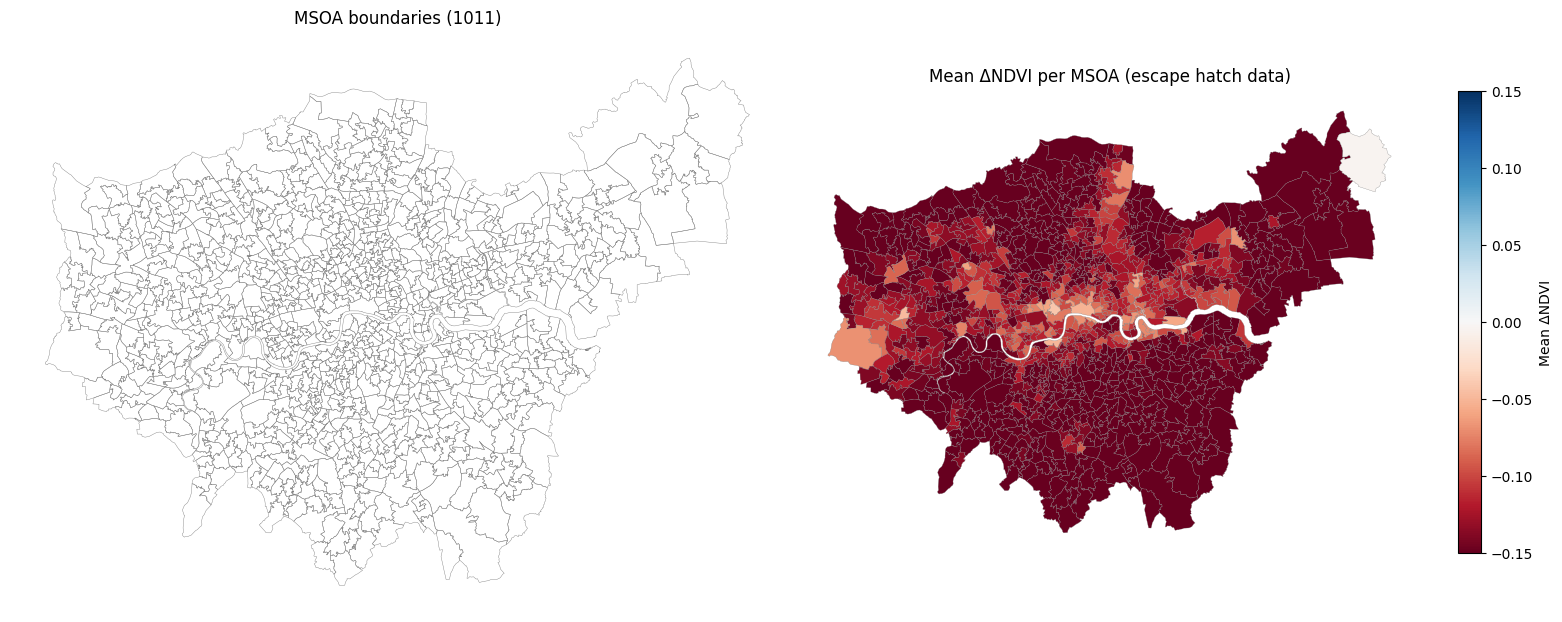

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

msoa_base.plot(ax=axes[0], edgecolor="grey", facecolor="none", linewidth=0.3)
axes[0].set_title(f"MSOA boundaries ({len(msoa_base)})")
axes[0].axis("off")

msoa_full.dropna(subset=["mean_delta_ndvi"]).plot(
    column="mean_delta_ndvi", cmap="RdBu", vmin=-0.15, vmax=0.15,
    ax=axes[1], edgecolor="grey", linewidth=0.2, legend=True,
    legend_kwds={"label": "Mean ΔNDVI", "shrink": 0.6},
)
axes[1].set_title("Mean ΔNDVI per MSOA (escape hatch data)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
n_total = len(msoa_full)
n_null = msoa_full["mean_delta_ndvi"].isna().sum()
print(f"{n_null}/{n_total} MSOAs with no NDVI data ({n_null/n_total*100:.1f}%)")

if n_null > 0:
    missing = msoa_full[msoa_full["mean_delta_ndvi"].isna()]
    print(f"Missing: {missing['MSOA21NM'].tolist()}")

1/1011 MSOAs with no NDVI data (0.1%)
Missing: ['Brentwood 003']


In [12]:
checks = []

checks.append(("Raster shape matches meta", ndvi_early.shape == tuple(meta["shape"])))
checks.append(("Both NDVI rasters same shape", ndvi_early.shape == ndvi_late.shape))
checks.append(("All bands same shape", len(set(a.shape for a in bands_early.values())) == 1))
checks.append(("NDVI in [-1, 1]", ndvi_early.min() >= -1 and ndvi_early.max() <= 1))
checks.append(("Base has >900 MSOAs", len(msoa_base) > 900))
checks.append(("Full has same rows as base", len(msoa_full) == len(msoa_base)))
checks.append(("Full has NDVI columns", "mean_delta_ndvi" in msoa_full.columns))
checks.append(("Population mostly present", msoa_base["population"].notna().mean() > 0.95))
checks.append(("<5% MSOAs missing coverage", n_null / n_total < 0.05))
checks.append(("CRS is EPSG:27700", meta["crs"] == "EPSG:27700"))

all_ok = True
for label, passed in checks:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_ok = False
    print(f"  [{status}] {label}")

print()
print("All checks passed." if all_ok else "Some checks failed — review above.")

  [PASS] Raster shape matches meta
  [PASS] Both NDVI rasters same shape
  [PASS] All bands same shape
  [PASS] NDVI in [-1, 1]
  [PASS] Base has >900 MSOAs
  [PASS] Full has same rows as base
  [PASS] Full has NDVI columns
  [PASS] Population mostly present
  [PASS] <5% MSOAs missing coverage
  [PASS] CRS is EPSG:27700

All checks passed.
